# 02. Exploratory Descriptive Analysis of Keyword Choices

## Research Objective
Examine how human selection probability varies as a function of **Condition** (`Ranked`, `Reverse`, `Shuffled`) and **Displayed Position** ($k \in \{1, \dots, 20\}$).

### Key Metrics
- **Mean Empirical Selection Rate**: $\hat{p}_{k, c} = rac{1}{N_{k,c}} \sum_{i=1}^{N_{k,c}} Y_{i, k, c}$
- **Standard Error of the Mean**: $	ext{SE}(\hat{p}_{k,c}) = \sqrt{rac{\hat{p}_{k,c}(1 - \hat{p}_{k,c})}{N_{k,c}}}$


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/mnt/data/h2_testing_dataset.csv')
print("Dataset size:", df.shape)


Dataset size: (18000, 6)


In [2]:
# Groupby condition and displayed_position
desc_stats = df.groupby(['condition', 'displayed_position']).agg(
    N=('selected', 'count'),
    selections=('selected', 'sum'),
    selection_rate=('selected', 'mean'),
    selection_std=('selected', 'std'),
    model_weight_mean=('model_weight', 'mean')
).reset_index()

desc_stats['selection_se'] = np.sqrt(desc_stats['selection_rate'] * (1 - desc_stats['selection_rate']) / desc_stats['N'])

print("Top 10 rows of descriptive summary:")
desc_stats.head(10)


Top 10 rows of descriptive summary:


,condition,displayed_position,N,selections,selection_rate,selection_std,model_weight_mean,selection_se
0,Ranked,1,375,373,0.994667,0.072932,0.100000,0.003761
1,Ranked,2,375,261,0.696000,0.460597,0.095263,0.023753
2,Ranked,3,375,159,0.424000,0.494850,0.090526,0.025520
3,Ranked,4,375,104,0.277333,0.448281,0.085789,0.023118
4,Ranked,5,375,55,0.146667,0.354246,0.081053,0.018269
5,Ranked,6,375,38,0.101333,0.302173,0.076316,0.015583
6,Ranked,7,375,28,0.074667,0.263204,0.071579,0.013574
7,Ranked,8,375,17,0.045333,0.208312,0.066842,0.010743
8,Ranked,9,375,12,0.032000,0.176235,0.062105,0.009089
9,Ranked,10,375,21,0.056000,0.230229,0.057368,0.011873


In [3]:
# Cross-tabulation of Selection Rate across Positional Deciles
df['position_quintile'] = pd.qcut(df['displayed_position'], q=4, labels=['Q1 (Top 1-5)', 'Q2 (6-10)', 'Q3 (11-15)', 'Q4 (16-20)'])
quintile_summary = df.groupby(['condition', 'position_quintile'])['selected'].agg(['count', 'mean', 'std']).reset_index()
print(quintile_summary)


   condition position_quintile  count      mean       std
0     Ranked      Q1 (Top 1-5)   1875  0.507733  0.500074
1     Ranked         Q2 (6-10)   1875  0.061867  0.240977
2     Ranked        Q3 (11-15)   1875  0.019733  0.139120
3     Ranked        Q4 (16-20)   1875  0.010667  0.102755
4    Reverse      Q1 (Top 1-5)    975  0.486154  0.500065
5    Reverse         Q2 (6-10)    975  0.078974  0.269837
6    Reverse        Q3 (11-15)    975  0.023590  0.151845
7    Reverse        Q4 (16-20)    975  0.011282  0.105670
8   Shuffled      Q1 (Top 1-5)   1650  0.507273  0.500099
9   Shuffled         Q2 (6-10)   1650  0.067879  0.251614
10  Shuffled        Q3 (11-15)   1650  0.015152  0.122192
11  Shuffled        Q4 (16-20)   1650  0.009697  0.098024


/tmp/ipykernel_34/2956075957.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quintile_summary = df.groupby(['condition', 'position_quintile'])['selected'].agg(['count', 'mean', 'std']).reset_index()


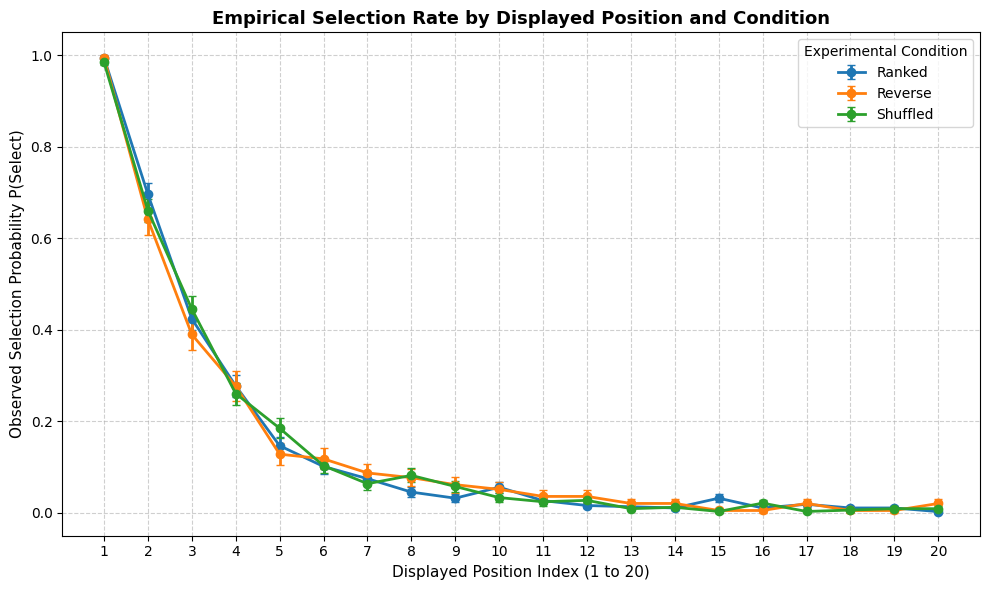

In [4]:
# Plot Descriptive Profiles across Conditions
plt.figure(figsize=(10, 6))
palette = {'Ranked': '#1f77b4', 'Reverse': '#ff7f0e', 'Shuffled': '#2ca02c'}

for cond, group in desc_stats.groupby('condition'):
    plt.errorbar(group['displayed_position'], group['selection_rate'], 
                 yerr=group['selection_se'], label=cond, marker='o', capsize=3, color=palette[cond], lw=2)

plt.title("Empirical Selection Rate by Displayed Position and Condition", fontsize=13, fontweight='bold')
plt.xlabel("Displayed Position Index (1 to 20)", fontsize=11)
plt.ylabel("Observed Selection Probability P(Select)", fontsize=11)
plt.xticks(range(1, 21))
plt.legend(title="Experimental Condition", frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
